In [2]:
 !git clone https://github.com/niaz1971/COTTON_LEAF_DISEASE_DATASET.git

Cloning into 'COTTON_LEAF_DISEASE_DATASET'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 34 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 16.21 MiB | 14.43 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [3]:
cd COTTON_LEAF_DISEASE_DATASET/

/content/COTTON_LEAF_DISEASE_DATASET


In [4]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp Kaggle_Cotton_Disease_Classification/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/Kaggle_Cotton_Disease_Classification/kaggle.json
!kaggle datasets download -d atrithakar/cotton-disease-classification

!pip install kaggle
!mkdir -p ~/.kaggle
!cp  Kaggle_Cotton-Leaf_Disease_Dataset/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/ Kaggle_Cotton-Leaf_Disease_Dataset/kaggle.json
!kaggle datasets download -d ataher/cotton-leaf-disease-dataset

chmod: cannot access '/root/.kaggle/Kaggle_Cotton_Disease_Classification/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/atrithakar/cotton-disease-classification
License(s): MIT
100% 507M/507M [00:02<00:00, 182MB/s]

Dataset URL: https://www.kaggle.com/datasets/ataher/cotton-leaf-disease-dataset
License(s): unknown
100% 452M/452M [00:06<00:00, 77.4MB/s]



In [5]:
!unzip -q cotton-disease-classification.zip
!unzip -q cotton-leaf-disease-dataset.zip
!rm -rf cotton-disease-classification.zip
!rm -rf cotton-leaf-disease-dataset.zip
!rm -rf Kaggle_Cotton_Disease_Classification
!rm -rf Kaggle_Cotton-Leaf_Disease_Dataset
!mkdir cotton-leaf-disease-dataset
!mv test cotton-leaf-disease-dataset
!mv train cotton-leaf-disease-dataset

In [6]:
!ls

 cotton-leaf-disease-dataset	      MobileNetV2.ipynb
'Main dataset-20230209T170929Z-001'   VGG16.ipynb


✅ TensorFlow: 2.20.0
Found 1920 images belonging to 6 classes.
Found 480 images belonging to 6 classes.
Found 3118 images belonging to 6 classes.

✅ Dataset loaded:
Train: 1920, Val: 480, Test: 3118
Classes: ['Aphids', 'Army worm', 'Bacterial Blight', 'Healthy', 'Powdery Mildew', 'Target spot']
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Model ready!

🚀 Training starts NOW (100% clean)...
Epoch 1/2
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.1551 - loss: 2.0600

60/60 ━━━━━━━━━━━━━━━━━━━━ 70s 804ms/step - accuracy: 0.1594 - loss: 2.0096 - val_accuracy: 0.2438 - val_loss: 1.7549 - learning_rate: 1.0000e-04
Epoch 2/2
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.1831 - loss: 1.9151

60/60 ━━━━━━━━━━━━━━━━━━━━ 49s 817ms/step - accuracy: 0.1932 - loss: 1.8918 - val_accuracy: 0.4083 - val_loss: 1.7099 - learning_rate: 1.0000e-04


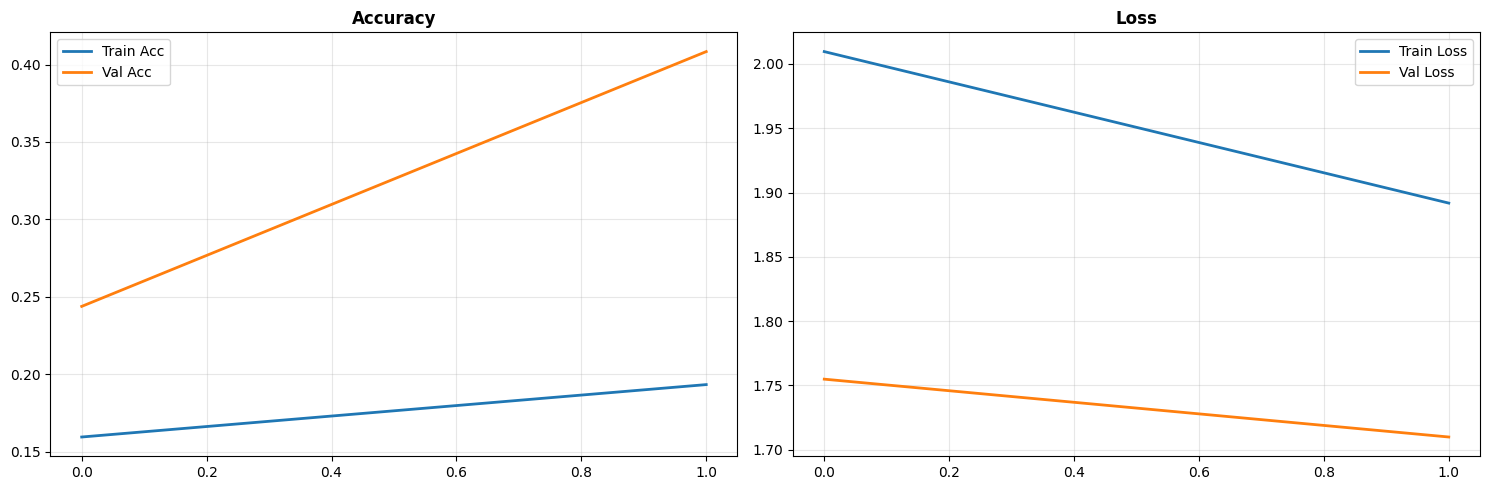


=== TEST RESULTS ===
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 312ms/step - accuracy: 0.4051 - loss: 1.6965
Test Accuracy: 0.4051
98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 253ms/step

Classification Report:
                  precision    recall  f1-score   support

          Aphids       0.39      0.64      0.48       520
       Army worm       0.50      0.32      0.39       520
Bacterial Blight       0.50      0.33      0.40       520
         Healthy       0.50      0.28      0.36       520
  Powdery Mildew       0.63      0.37      0.47       520
     Target spot       0.26      0.49      0.33       518

        accuracy                           0.41      3118
       macro avg       0.46      0.41      0.41      3118
    weighted avg       0.46      0.41      0.41      3118



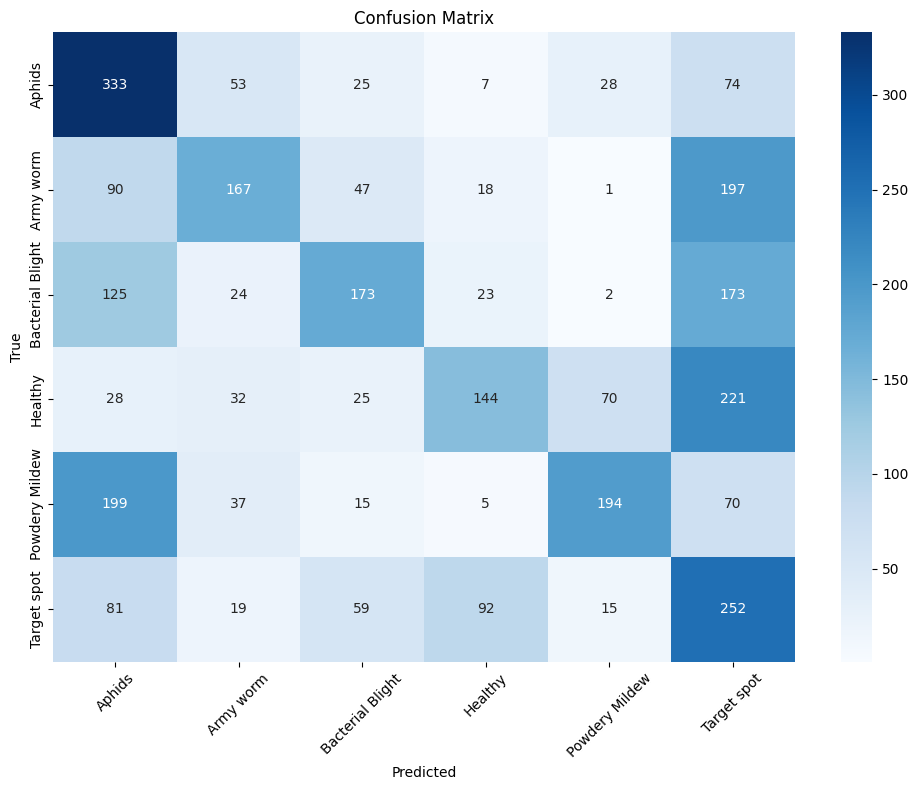


✅ COMPLETE! Models saved.


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# SUPPRESS ALL WARNINGS (simplest fix)
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
tf.random.set_seed(42)
np.random.seed(42)

print("✅ TensorFlow:", tf.__version__)

# Dataset paths
dataset1_path = "Main dataset-20230209T170929Z-001/Main dataset"
dataset2_path = "cotton-leaf-disease-dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data generators (EXACT SAME as before)
train_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=20, width_shift_range=0.2, height_shift_range=0.2,
    horizontal_flip=True, zoom_range=0.2, fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
dataset2_train_path = os.path.join(dataset2_path, "train")
train_generator = train_datagen.flow_from_directory(
    dataset2_train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    dataset2_train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    dataset1_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Dataset info
class_names = list(train_generator.class_indices.keys())
print(f"\n✅ Dataset loaded:")
print(f"Train: {train_generator.samples}, Val: {val_generator.samples}, Test: {test_generator.samples}")
print(f"Classes: {class_names}")

# Model (Swapped to VGG19)
def create_model(num_classes):
    # Load VGG19 base without top classifier layers
    base_model = tf.keras.applications.VGG19(
        input_shape=(224, 224, 3), include_top=False, weights='imagenet'
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(), # Flattens the feature maps to 1D vector
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = create_model(len(class_names))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel ready!")

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=3, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint('best_cotton_model.h5', save_best_only=True, monitor='val_accuracy')
]

# TRAIN - NO WARNINGS!
print("\n🚀 Training starts NOW (100% clean)...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=2,  #30,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# Plotting function
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history.history['accuracy'], label='Train Acc', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
    ax1.set_title('Accuracy', fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title('Loss', fontweight='bold')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Test evaluation
print("\n=== TEST RESULTS ===")
test_generator.reset()
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")

# Classification report & confusion matrix
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save models
model.save('cotton_disease_final.h5')
print("\n✅ COMPLETE! Models saved.")

In [8]:
!ls

 best_cotton_model.h5	      'Main dataset-20230209T170929Z-001'
 cotton_disease_final.h5       MobileNetV2.ipynb
 cotton-leaf-disease-dataset   VGG16.ipynb


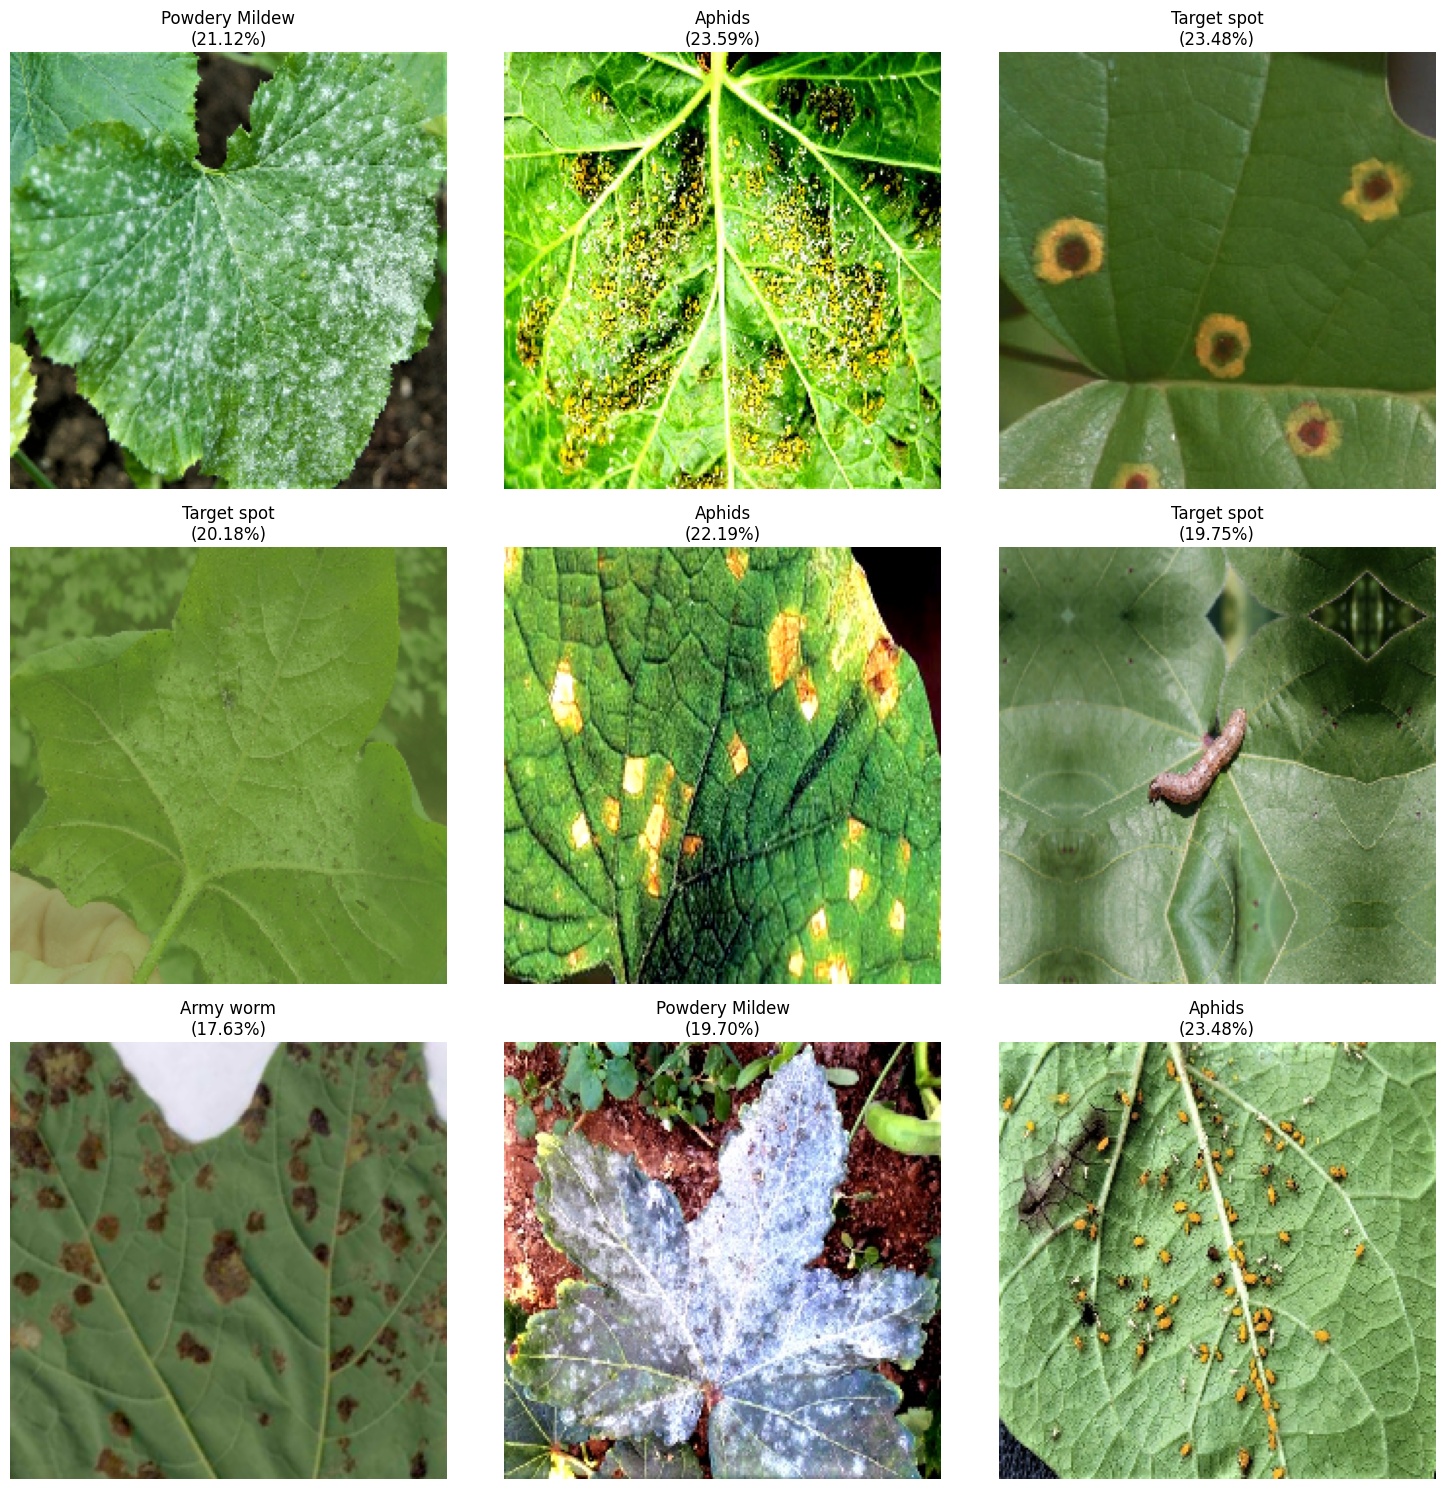

Prediction functions are ready to use!


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import random

# Load your trained model
model = load_model('best_cotton_model.h5')

# Define class names (from your training output)
class_names = ['Aphids', 'Army worm', 'Bacterial Blight', 'Healthy', 'Powdery Mildew', 'Target spot']

# Function to predict and display an image
def predict_and_display(img_path, model, class_names):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize like in training

    # Make prediction
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0])

    # Get all class probabilities
    class_probabilities = {class_names[i]: float(prediction[0][i]) for i in range(len(class_names))}

    # Sort by probability
    sorted_probs = dict(sorted(class_probabilities.items(), key=lambda item: item[1], reverse=True))

    # Display the image with prediction
    plt.figure(figsize=(10, 8))

    # Show image
    plt.subplot(2, 1, 1)
    plt.imshow(img)
    plt.title(f'Predicted: {class_names[predicted_class]} (Confidence: {confidence:.2%})')
    plt.axis('off')

    # Show probabilities as bar chart
    plt.subplot(2, 1, 2)
    colors = ['green' if c == class_names[predicted_class] else 'blue' for c in sorted_probs.keys()]
    plt.barh(range(len(sorted_probs)), list(sorted_probs.values()), color=colors)
    plt.yticks(range(len(sorted_probs)), list(sorted_probs.keys()))
    plt.xlabel('Probability')
    plt.title('Class Probabilities')
    plt.tight_layout()
    plt.show()

    return class_names[predicted_class], confidence, class_probabilities

# Function to display multiple predictions in a grid
def display_predictions_grid(image_paths, model, class_names, grid_size=(3, 3)):
    fig, axes = plt.subplots(grid_size[0], grid_size[1], figsize=(15, 15))
    axes = axes.ravel()

    for i, img_path in enumerate(image_paths[:grid_size[0]*grid_size[1]]):
        # Load and preprocess the image
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0

        # Make prediction
        prediction = model.predict(img_array, verbose=0)
        predicted_class = np.argmax(prediction[0])
        confidence = np.max(prediction[0])

        # Display the image with prediction
        axes[i].imshow(img)
        axes[i].set_title(f'{class_names[predicted_class]}\n({confidence:.2%})', fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Function to get random samples from a directory
def get_random_samples(directory, num_samples=9):
    all_images = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_images.append(os.path.join(root, file))

    return random.sample(all_images, min(num_samples, len(all_images)))

# Example usage
if __name__ == "__main__":
    # Option 1: Predict and display a single image
    # Replace with the path to your test image
    # test_image_path = "/path/to/your/test/image.jpg"
    # predict_and_display(test_image_path, model, class_names)

    # Option 2: Display multiple random images from a directory
    # Replace with path to a directory containing cotton leaf images
    sample_directory = "Main dataset-20230209T170929Z-001/Main dataset"
    sample_images = get_random_samples(sample_directory, 9)
    display_predictions_grid(sample_images, model, class_names, grid_size=(3, 3))

    print("Prediction functions are ready to use!")

98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 252ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 25s 251ms/step
Total test samples: 3118
Misclassified samples: 1855
Accuracy: 40.51%


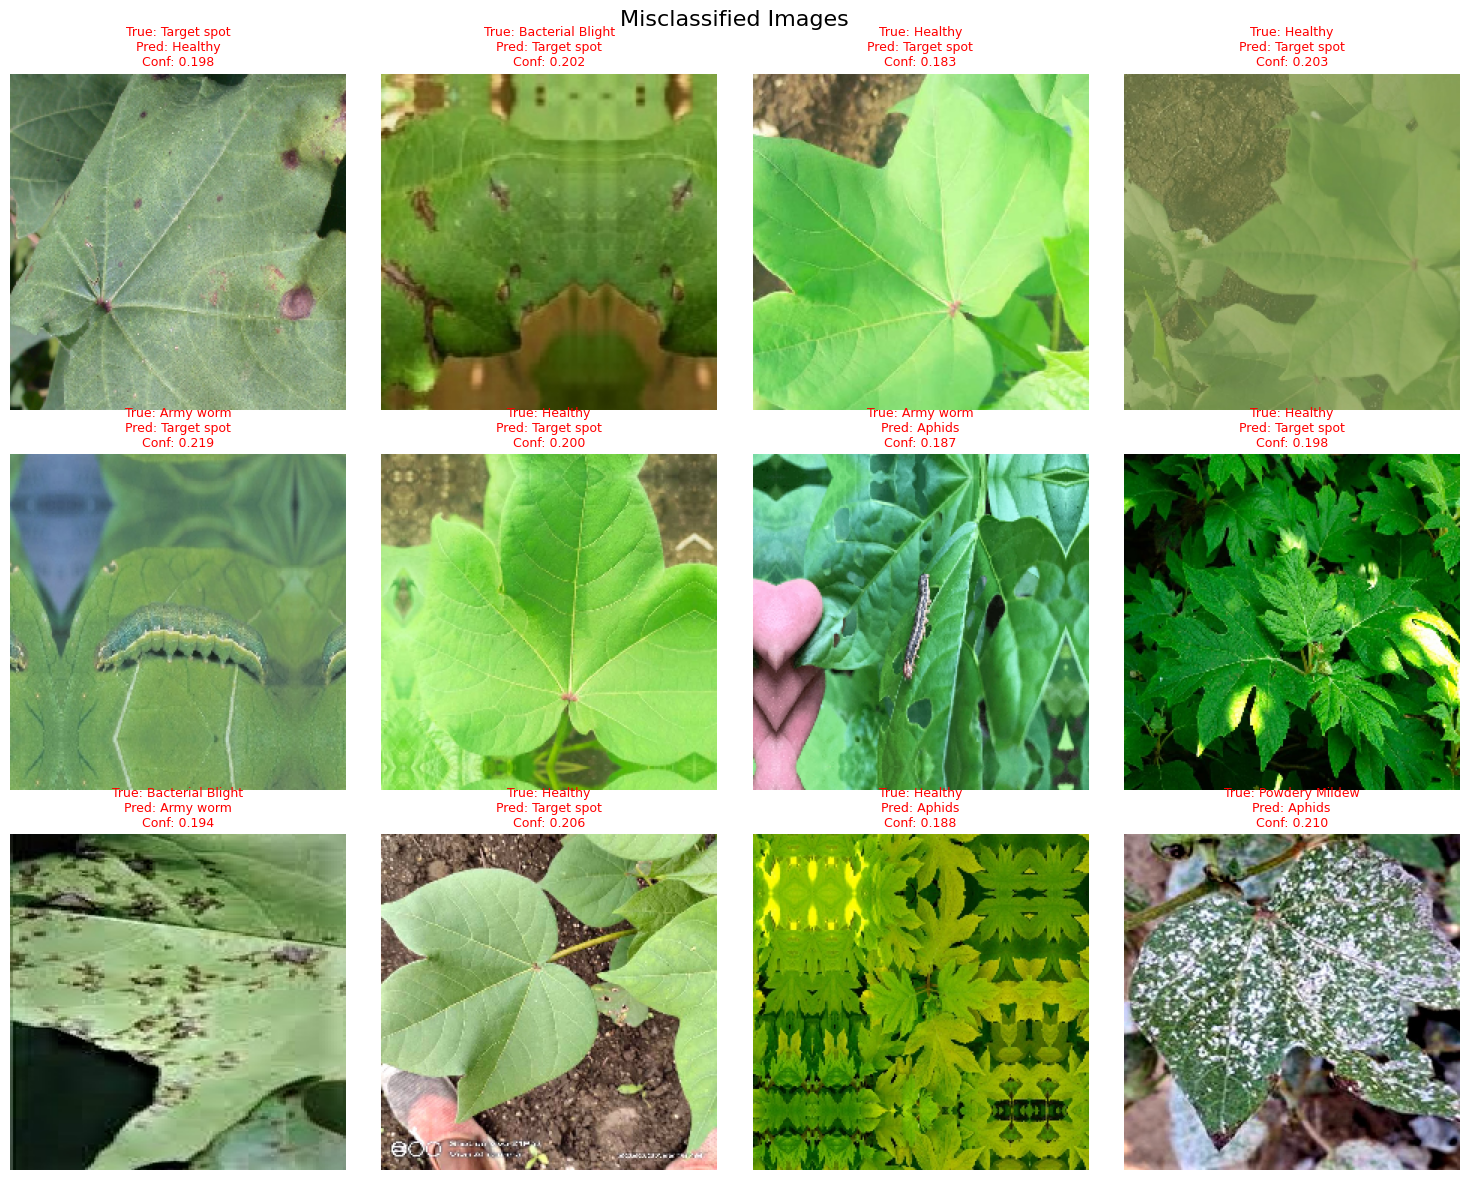


Error Rate by Class:
              Class  Total Samples  Misclassifications  Error Rate
3           Healthy            520                 376   72.307692
1         Army worm            520                 353   67.884615
2  Bacterial Blight            520                 347   66.730769
4    Powdery Mildew            520                 326   62.692308
5       Target spot            518                 266   51.351351
0            Aphids            520                 187   35.961538


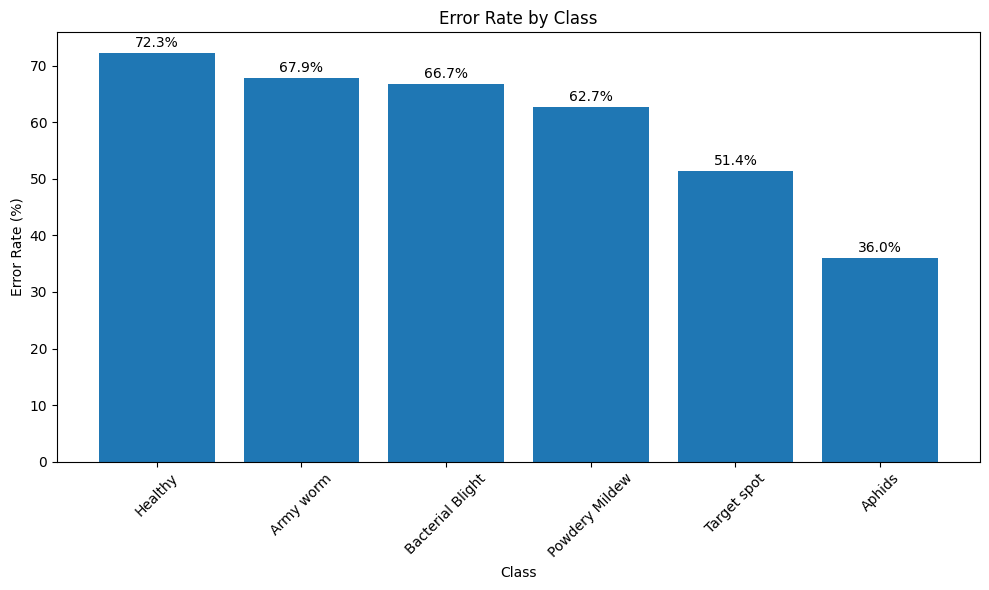


Most Common Misclassification Patterns:
          true_label predicted_label  count
19           Healthy     Target spot    221
20    Powdery Mildew          Aphids    199
9          Army worm     Target spot    197
14  Bacterial Blight     Target spot    173
10  Bacterial Blight          Aphids    125
28       Target spot         Healthy     92
5          Army worm          Aphids     90
25       Target spot          Aphids     81
4             Aphids     Target spot     74
24    Powdery Mildew     Target spot     70


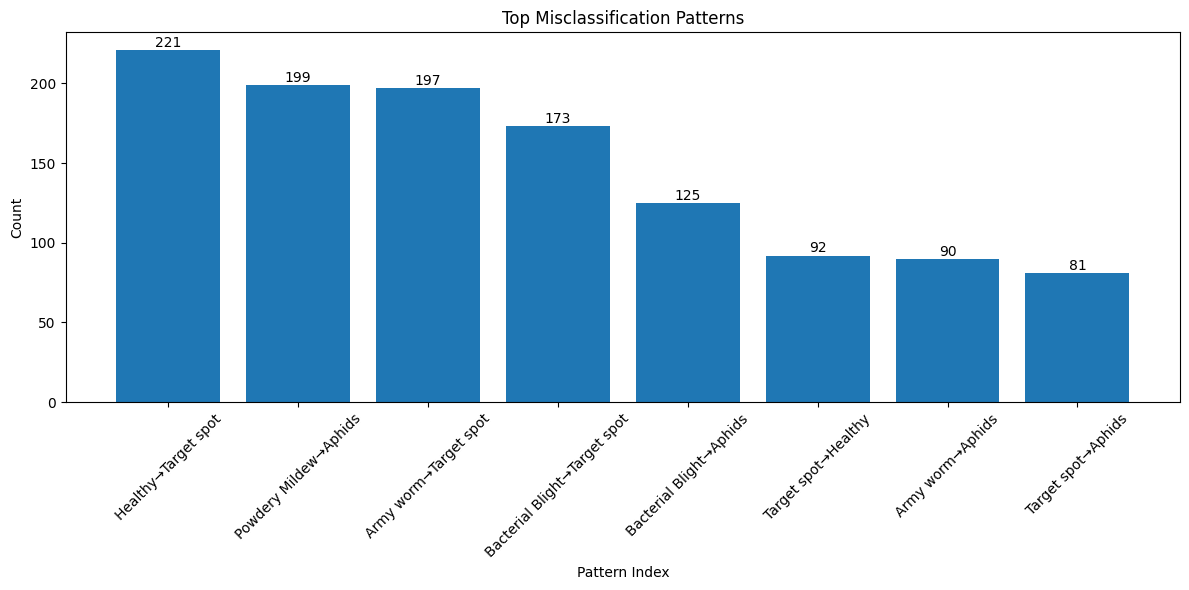

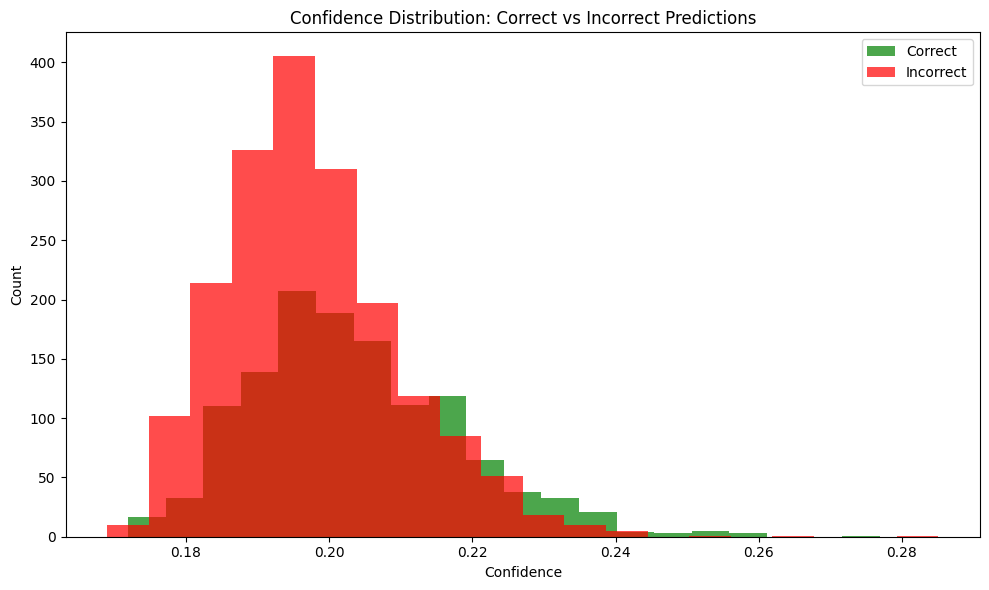


Confidence Statistics:
   correct      mean    median       std
0    False  0.197677  0.196227  0.012422
1     True  0.203489  0.201730  0.014524

High-confidence errors (confidence > 0.8): 0

Low-confidence correct predictions (confidence < 0.6): 1263

Error analysis completed. Check the generated images and report for insights.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from tensorflow.keras.preprocessing import image
import seaborn as sns

# Get predictions and true labels for the test set
test_generator.reset()
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)
y_probs = model.predict(test_generator)

# Get filenames for the test set
filenames = test_generator.filenames

# Create a DataFrame for analysis
results_df = pd.DataFrame({
    'filename': filenames,
    'true_label': [class_names[i] for i in y_true],
    'predicted_label': [class_names[i] for i in y_pred],
    'confidence': [np.max(y_probs[i]) for i in range(len(y_probs))],
    'correct': y_true == y_pred
})

# Filter misclassified images
misclassified_df = results_df[results_df['correct'] == False]

print(f"Total test samples: {len(results_df)}")
print(f"Misclassified samples: {len(misclassified_df)}")
print(f"Accuracy: {(len(results_df) - len(misclassified_df)) / len(results_df) * 100:.2f}%")

# 1. Display misclassified images with predictions and confidence
def display_misclassified_images(misclassified_df, num_samples=12):
    # Randomly select misclassified samples
    samples = misclassified_df.sample(min(num_samples, len(misclassified_df)))

    # Create a grid of images
    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    axes = axes.ravel()

    for i, (idx, row) in enumerate(samples.iterrows()):
        # Load and display image - CORRECTED PATH
        img_path = os.path.join(dataset1_path, row['filename'])  # Changed from dataset2_path to dataset1_path
        img = image.load_img(img_path, target_size=(224, 224))

        axes[i].imshow(img)
        axes[i].set_title(f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.3f}",
                         fontsize=9, color='red')
        axes[i].axis('off')

    plt.suptitle('Misclassified Images', fontsize=16)
    plt.tight_layout()
    plt.savefig('misclassified_images.png')
    plt.show()

display_misclassified_images(misclassified_df)

# 2. Analyze misclassifications by class
misclassification_by_class = results_df.groupby('true_label').agg({
    'correct': ['count', lambda x: sum(x == False)]
}).reset_index()

misclassification_by_class.columns = ['Class', 'Total Samples', 'Misclassifications']
misclassification_by_class['Error Rate'] = misclassification_by_class['Misclassifications'] / misclassification_by_class['Total Samples'] * 100
misclassification_by_class = misclassification_by_class.sort_values('Error Rate', ascending=False)

print("\nError Rate by Class:")
print(misclassification_by_class)

# Plot error rates by class
plt.figure(figsize=(10, 6))
bars = plt.bar(misclassification_by_class['Class'], misclassification_by_class['Error Rate'])
plt.title('Error Rate by Class')
plt.xlabel('Class')
plt.ylabel('Error Rate (%)')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('error_rate_by_class.png')
plt.show()

# 3. Most common misclassification patterns
misclassification_patterns = results_df[results_df['correct'] == False].groupby(
    ['true_label', 'predicted_label']).size().reset_index(name='count')
misclassification_patterns = misclassification_patterns.sort_values('count', ascending=False)

print("\nMost Common Misclassification Patterns:")
print(misclassification_patterns.head(10))

# Visualize common misclassification patterns
plt.figure(figsize=(12, 6))
top_patterns = misclassification_patterns.head(8)
bars = plt.bar(range(len(top_patterns)), top_patterns['count'])
plt.title('Top Misclassification Patterns')
plt.xlabel('Pattern Index')
plt.ylabel('Count')
plt.xticks(range(len(top_patterns)),
           [f"{row['true_label']}→{row['predicted_label']}" for _, row in top_patterns.iterrows()],
           rotation=45)

# Add value labels on bars
for bar, count in zip(bars, top_patterns['count']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
             str(count), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('top_misclassification_patterns.png')
plt.show()

# 4. Analyze confidence of misclassifications vs correct classifications
plt.figure(figsize=(10, 6))

# Plot confidence distribution for correct and incorrect predictions
plt.hist(results_df[results_df['correct'] == True]['confidence'],
         alpha=0.7, label='Correct', bins=20, color='green')
plt.hist(results_df[results_df['correct'] == False]['confidence'],
         alpha=0.7, label='Incorrect', bins=20, color='red')

plt.title('Confidence Distribution: Correct vs Incorrect Predictions')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('confidence_distribution.png')
plt.show()

# 5. Analyze confidence statistics
confidence_stats = results_df.groupby('correct')['confidence'].agg(['mean', 'median', 'std']).reset_index()
print("\nConfidence Statistics:")
print(confidence_stats)

# 6. Examine high-confidence errors (potentially problematic cases)
high_confidence_errors = misclassified_df[misclassified_df['confidence'] > 0.8]
print(f"\nHigh-confidence errors (confidence > 0.8): {len(high_confidence_errors)}")
if len(high_confidence_errors) > 0:
    print("These cases represent potentially serious model errors:")
    for _, row in high_confidence_errors.iterrows():
        print(f"  {row['filename']}: True={row['true_label']}, Pred={row['predicted_label']}, Conf={row['confidence']:.3f}")

# 7. Examine low-confidence correct predictions (potentially lucky guesses)
low_confidence_correct = results_df[(results_df['correct'] == True) & (results_df['confidence'] < 0.6)]
print(f"\nLow-confidence correct predictions (confidence < 0.6): {len(low_confidence_correct)}")

# 8. Generate a detailed error analysis report
def generate_error_report(results_df, misclassification_patterns, misclassified_df):
    report = {
        'total_samples': len(results_df),
        'misclassified_samples': len(misclassified_df),
        'overall_accuracy': (len(results_df) - len(misclassified_df)) / len(results_df) * 100,
        'class_wise_error_rates': misclassification_by_class.to_dict('records'),
        'common_misclassification_patterns': misclassification_patterns.head(10).to_dict('records'),
        'average_confidence_correct': results_df[results_df['correct'] == True]['confidence'].mean(),
        'average_confidence_incorrect': results_df[results_df['correct'] == False]['confidence'].mean(),
        'high_confidence_errors': len(misclassified_df[misclassified_df['confidence'] > 0.8]),
        'low_confidence_correct': len(results_df[(results_df['correct'] == True) & (results_df['confidence'] < 0.6)])
    }

    # Save report
    with open('error_analysis_report.txt', 'w') as f:
        f.write("COTTON DISEASE CLASSIFICATION ERROR ANALYSIS REPORT\n")
        f.write("====================================================\n\n")
        f.write(f"Overall Accuracy: {report['overall_accuracy']:.2f}%\n")
        f.write(f"Misclassified Samples: {report['misclassified_samples']}/{report['total_samples']}\n\n")

        f.write("Class-wise Error Rates:\n")
        for item in report['class_wise_error_rates']:
            f.write(f"{item['Class']}: {item['Error Rate']:.2f}% ({item['Misclassifications']}/{item['Total Samples']})\n")

        f.write("\nMost Common Misclassification Patterns:\n")
        for item in report['common_misclassification_patterns']:
            f.write(f"{item['true_label']} -> {item['predicted_label']}: {item['count']} times\n")

        f.write(f"\nAverage Confidence for Correct Predictions: {report['average_confidence_correct']:.3f}\n")
        f.write(f"Average Confidence for Incorrect Predictions: {report['average_confidence_incorrect']:.3f}\n")
        f.write(f"High-confidence Errors (confidence > 0.8): {report['high_confidence_errors']}\n")
        f.write(f"Low-confidence Correct Predictions (confidence < 0.6): {report['low_confidence_correct']}\n")

    return report

error_report = generate_error_report(results_df, misclassification_patterns, misclassified_df)

print("\nError analysis completed. Check the generated images and report for insights.")

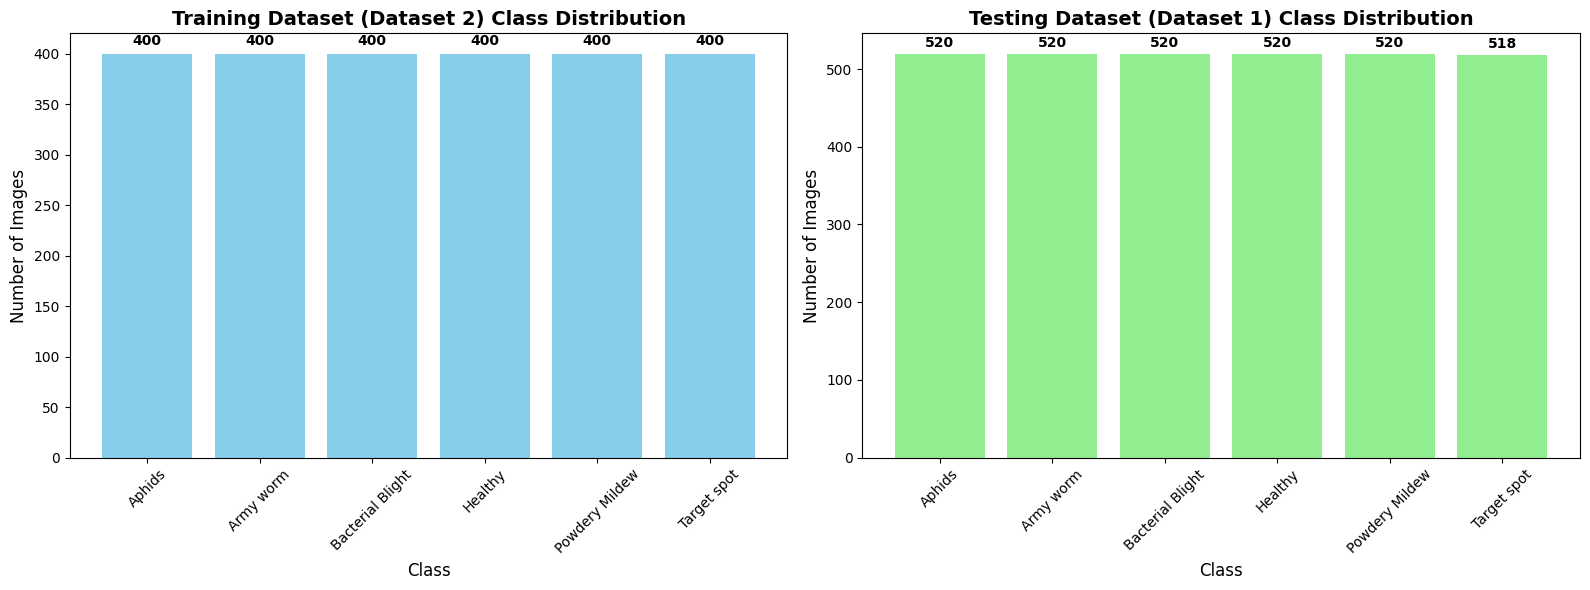

DATASET CLASS DISTRIBUTION SUMMARY

Training Dataset (Dataset 2 - train folder) Class Distribution:
  Aphids: 400 images
  Army worm: 400 images
  Bacterial Blight: 400 images
  Healthy: 400 images
  Powdery Mildew: 400 images
  Target spot: 400 images

Testing Dataset (Dataset 1) Class Distribution:
  Aphids: 520 images
  Army worm: 520 images
  Bacterial Blight: 520 images
  Healthy: 520 images
  Powdery Mildew: 520 images
  Target spot: 518 images

Total training images: 2400
Total testing images: 3118
Total images across both datasets: 5518

CLASS BALANCE ANALYSIS

Training Dataset Class Balance:
  Aphids: 400 images (16.7%)
  Army worm: 400 images (16.7%)
  Bacterial Blight: 400 images (16.7%)
  Healthy: 400 images (16.7%)
  Powdery Mildew: 400 images (16.7%)
  Target spot: 400 images (16.7%)

Testing Dataset Class Balance:
  Aphids: 520 images (16.7%)
  Army worm: 520 images (16.7%)
  Bacterial Blight: 520 images (16.7%)
  Healthy: 520 images (16.7%)
  Powdery Mildew: 520 images 

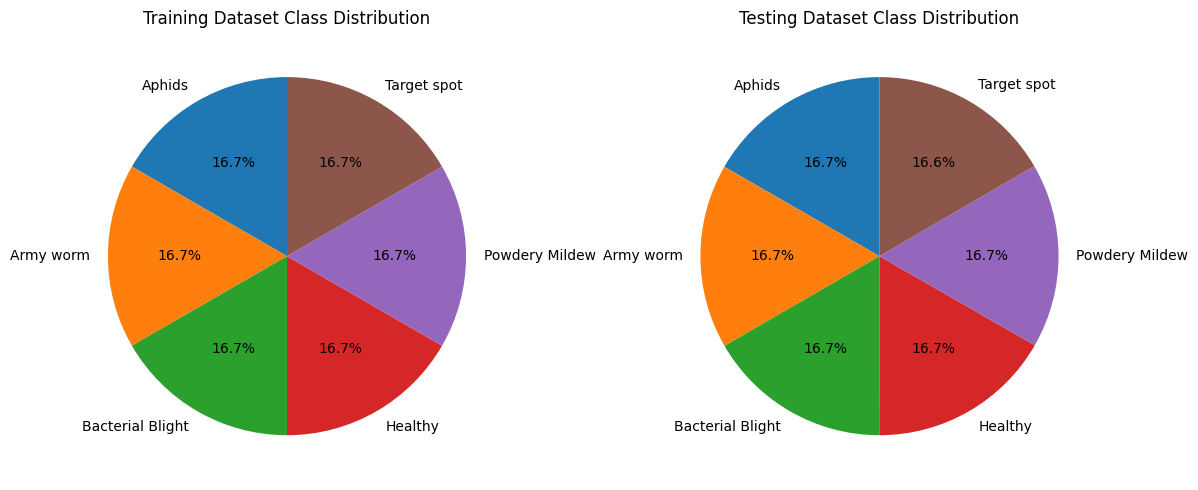


CLASS DISTRIBUTION COMPARISON TABLE
Class                Train Count  Test Count   Total      Train %    Test %    
--------------------------------------------------------------------------------
Aphids               400          520          920        16.7%      16.7%     
Army worm            400          520          920        16.7%      16.7%     
Bacterial Blight     400          520          920        16.7%      16.7%     
Healthy              400          520          920        16.7%      16.7%     
Powdery Mildew       400          520          920        16.7%      16.7%     
Target spot          400          518          918        16.7%      16.6%     


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Get class distribution for training dataset (Dataset 2 - train folder)
train_class_counts = {}
for class_name in class_names:
    class_dir = os.path.join(dataset2_path, "train", class_name)
    train_class_counts[class_name] = len(os.listdir(class_dir))

# Get class distribution for testing dataset (Dataset 1)
test_class_counts = {}
for class_name in class_names:
    class_dir = os.path.join(dataset1_path, class_name)
    test_class_counts[class_name] = len(os.listdir(class_dir))

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot training dataset class distribution
bars1 = ax1.bar(train_class_counts.keys(), train_class_counts.values(), color='skyblue')
ax1.set_title('Training Dataset (Dataset 2) Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Number of Images', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars for training dataset
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height}', ha='center', va='bottom', fontweight='bold')

# Plot testing dataset class distribution
bars2 = ax2.bar(test_class_counts.keys(), test_class_counts.values(), color='lightgreen')
ax2.set_title('Testing Dataset (Dataset 1) Class Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Class', fontsize=12)
ax2.set_ylabel('Number of Images', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars for testing dataset
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print numerical summary
print("="*60)
print("DATASET CLASS DISTRIBUTION SUMMARY")
print("="*60)
print("\nTraining Dataset (Dataset 2 - train folder) Class Distribution:")
for class_name, count in train_class_counts.items():
    print(f"  {class_name}: {count} images")

print("\nTesting Dataset (Dataset 1) Class Distribution:")
for class_name, count in test_class_counts.items():
    print(f"  {class_name}: {count} images")

print(f"\nTotal training images: {sum(train_class_counts.values())}")
print(f"Total testing images: {sum(test_class_counts.values())}")
print(f"Total images across both datasets: {sum(train_class_counts.values()) + sum(test_class_counts.values())}")

# Calculate and display class balance percentages
print("\n" + "="*60)
print("CLASS BALANCE ANALYSIS")
print("="*60)

print("\nTraining Dataset Class Balance:")
for class_name, count in train_class_counts.items():
    percentage = (count / sum(train_class_counts.values())) * 100
    print(f"  {class_name}: {count} images ({percentage:.1f}%)")

print("\nTesting Dataset Class Balance:")
for class_name, count in test_class_counts.items():
    percentage = (count / sum(test_class_counts.values())) * 100
    print(f"  {class_name}: {count} images ({percentage:.1f}%)")

# Create a pie chart for training dataset class distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie(train_class_counts.values(), labels=train_class_counts.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Training Dataset Class Distribution')

plt.subplot(1, 2, 2)
plt.pie(test_class_counts.values(), labels=test_class_counts.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Testing Dataset Class Distribution')

plt.tight_layout()
plt.savefig('dataset_class_pie_charts.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a comparison table
comparison_data = []
for class_name in class_names:
    train_count = train_class_counts[class_name]
    test_count = test_class_counts[class_name]
    total_count = train_count + test_count
    train_percentage = (train_count / sum(train_class_counts.values())) * 100
    test_percentage = (test_count / sum(test_class_counts.values())) * 100
    comparison_data.append([class_name, train_count, test_count, total_count, f"{train_percentage:.1f}%", f"{test_percentage:.1f}%"])

# Display comparison table
print("\n" + "="*80)
print("CLASS DISTRIBUTION COMPARISON TABLE")
print("="*80)
print(f"{'Class':<20} {'Train Count':<12} {'Test Count':<12} {'Total':<10} {'Train %':<10} {'Test %':<10}")
print("-"*80)
for row in comparison_data:
    print(f"{row[0]:<20} {row[1]:<12} {row[2]:<12} {row[3]:<10} {row[4]:<10} {row[5]:<10}")